**EXTRA CREDIT ASSIGNMENT **


**Decision Trees For Fantasy Football Analysis **
For this decision tree analysis, I pulled data from my own fantasy football league's API and FantasyPros player scores information. Here is the link to that website https://www.fantasypros.com/nfl/reports/leaders/ppr-wr.php?year=2024. 

The goal of this analysis is to find the best fantasy football drafting strategy by comparing how teams in my fantasy football league draftand  by finding out their tendencies and strategies. 

For some background, fantasy football is a game where players(team managers/owners) draft their own teams based off real life NFL athletes, and the performances of those athletes in real games dictate the performance of their own team in head to head matchups against other team managers in a fantasy league. You can draft any player from any team in the NFL if they are not drafted first by another team manager. My fantasy league drafts in a "snake" format so the first pick gets to draft once and the last pick gets to draft twice by drafting at the end of the round and at the start of the next one. This will go on for around 14-15 rounds until the draft is over. 

There is a lot of variability to draft strategies in fantasy football. Some team managers prefer creating RB(running back) dominant teams, others prefer drafting WR(wide receiver) dominant teams. Others prefer targeting a QB-TE(quarter back-tight end) stack. 

It is my belief that it is best to target dominant WRs than dominant RBs as there tends to be more valuable RBs in later rounds, and RBs are more injury prone due to their usage in real life. 

Prior to performing the decision trees analysis, I'd like to see the standard deviation, and the mean of the top WRs, RBs, and QBs in fantasy football to find trends in the scoring of each position in the PPR(Points Per Reception) format.



First performing all the necessary imports...

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.metrics import log_loss, accuracy_score, brier_score_loss
import numpy as np

Now to show some of the dataset.

In [3]:
data = pd.read_csv('fantasy_top20_merged.csv')
data.head(10)


,Year,Rank_PPR,Player,Pos,Team,GP,1,2,3,4,...,11,12,13,14,15,16,17,18,AVG,TTL
0,2024,1,Lamar Jackson,QB,BAL,17,25.1,17.4,26,23.6,...,15.9,22.6,25.4,BYE,36.1,21.5,29.4,23,25.6,434.4
1,2024,2,Josh Allen,QB,BUF,17,31.2,9.8,30.9,7.3,...,25,BYE,28.4,51.9,41.3,12.2,23,0,22.6,385.0
2,2024,3,Joe Burrow,QB,CIN,17,8.1,17.2,25.4,17.3,...,29,BYE,20.3,25.6,18.8,22,37,14,22.5,381.8
3,2024,3,Baker Mayfield,QB,TB,17,29.7,19.8,9.5,28.9,...,BYE,18.7,12.2,21,29,23.3,34.6,22.6,22.5,381.8
4,2024,5,Jayden Daniels,QB,WAS,17,28.2,13.4,28.1,25,...,14.4,32.4,28.6,BYE,23.6,36.4,32.8,4.2,21.5,364.8
5,2024,6,Jared Goff,QB,DET,17,12.4,10.8,15.6,26.2,...,34.6,10.8,16.9,23,41.1,25.3,25.8,11.2,19.7,335.5
6,2024,7,Bo Nix,QB,DEN,17,13,10.3,19.3,6.7,...,28.8,19.4,14.2,BYE,16.5,21,22.9,33.5,19.3,328.2
7,2024,8,Jalen Hurts,QB,PHI,15,18.4,24.8,11.9,16.3,...,18.7,15.1,17.6,24.2,28.1,4.5,-,-,21.3,320.1
8,2024,9,Sam Darnold,QB,SEA,17,15.6,20.9,23.2,21.5,...,23.6,21.1,19.6,34.6,12.2,22.9,25.8,7.6,18.8,320.0
9,2024,10,Kyler Murray,QB,MIN,17,14.2,28.5,15.8,10,...,-,11.3,17.2,20,10.1,21.4,18,27.9,18.1,308.2


In [4]:
data.tail(10)

,Year,Rank_PPR,Player,Pos,Team,GP,1,2,3,4,...,11,12,13,14,15,16,17,18,AVG,TTL
290,2021,11,Keenan Allen,WR,LAC,16,19,14.8,19,10.6,...,20.2,15.5,22.4,-,19.8,7.5,14.4,11.2,16.1,257.8
291,2021,12,Mike Williams,WR,FA,16,22.2,22.1,33.2,2.1,...,20.7,7.9,16,12.1,7.9,-,15.3,26.9,15.4,246.6
292,2021,13,Jaylen Waddle,WR,DEN,16,16.1,8.8,17.8,6.3,...,20.6,28.7,18,-,-,25.2,7.7,13.7,15.4,245.8
293,2021,14,DK Metcalf,WR,PIT,17,16,11.3,22.7,16.5,...,7.1,2.3,11,8.3,11.2,12.1,30.9,10.8,14.4,244.3
294,2021,15,Chris Godwin Jr.,WR,TB,14,23.5,16.2,19.6,8.5,...,19.2,4.7,30.2,20.5,10.9,-,-,-,17.3,242.4
295,2021,16,Tyler Lockett,WR,LV,16,26,31.8,7.1,6.4,...,15.5,12.6,19.8,27.2,-,6,12.1,27,15.1,241.4
296,2021,17,Michael Pittman Jr.,WR,PIT,17,5.9,20.3,13.3,11.9,...,4.3,9.3,17,-,1.7,16.5,10.7,20.4,14.0,238.6
297,2021,18,DJ Moore,WR,BUF,17,15.4,21.9,20.5,31.9,...,16,14.3,-,14.4,12.8,10.5,5.9,17,14.0,237.5
298,2021,19,CeeDee Lamb,WR,DAL,16,23.4,17.4,9.5,3.3,...,4.4,-,19.2,14.6,11,10.4,8.1,6.5,14.6,232.8
299,2021,20,Brandin Cooks,WR,FA,16,18.2,22.8,20.7,9.7,...,3.8,13.5,8.4,18.1,29.2,-,19.6,5.6,14.5,231.8


** Exploring the Dataset **
This data has been pulled from the FantasyPros website. It is the PPR (points per reception) scoring of the top 20 NFL athletes in the QB, RB, and WR positions from the years 2021-2025. I compiled this information separately, otherwise it would result in having 10+ CSV files in this project. PPR means players get points for catching the ball. This allows for wide receivers to be more valuable and even compete with running backs and quarter backs.

The headings in this csv are Year, Rank_PPR, Player, Pos, Team, GP, 1-18(These are the scoring for each week they played, players play one game a week), AVG, TTL.

Below I'll create a function that gets the mean and the standard deviation of whatever inputed position.


In [5]:
def get_mean_std(df, pos, year):
    
    copy_df = df.copy()
    copy_df = copy_df[(copy_df['Pos'] == pos) & (copy_df['Year'] == year)]
    
    mean_points = copy_df['AVG'].mean()
    stdev_points = copy_df['AVG'].std()
    
    
    return mean_points,stdev_points
    

    
    
pos = 'WR'
year = 2025
res = get_mean_std(data,pos,year)
print(res[0])
print(f"For the year: {year}, the mean is: {res[0]}, and the standard deviation is: {res[1]} for the {pos} position")

15.459999999999999
For the year: 2025, the mean is: 15.459999999999999, and the standard deviation is: 3.275009039762534 for the WR position


In [6]:
pos = 'RB'
year = 2025
res = get_mean_std(data,pos,year)
print(f"For the year: {year}, the mean is: {res[0]}, and the standard deviation is: {res[1]} for the {pos} position")

For the year: 2025, the mean is: 16.464999999999996, and the standard deviation is: 3.564041910084968 for the RB position


Here we see that mean and standard deviation for the positions.

** Plotting Mean and Standard Deviation **

Now we can plot the mean and the standard deviation to get a better understanding of how to draft. First lets create a dataframe with the year, the position, the mean, and the standard dev.

We can actually expedite the process by using the agg function to perform the mean and standard deviation for each position. Here we also order it by year in the new_df.columns section where I can easily choose the order for the columns while also renaming the aggregated colum

In [7]:
def make_data_4_plot(df):
    
    new_df = df.copy()
    new_df = new_df.groupby(['Year', 'Pos'])['AVG'].agg(['mean', 'std']).reset_index()
    new_df.columns = ['Year', 'Position', 'Mean', 'Standard Dev']
    return new_df


plot_data = make_data_4_plot(data)        
make_data_4_plot(data)

,Year,Position,Mean,Standard Dev
0,2021,QB,19.180,3.328442
1,2021,RB,15.875,2.840473
2,2021,WR,16.985,3.025379
3,2022,QB,18.890,3.158431
4,2022,RB,15.515,2.913900
5,2022,WR,16.160,2.535309
6,2023,QB,18.320,2.300252
7,2023,RB,15.915,2.916789
8,2023,WR,17.065,2.998995
9,2024,QB,18.590,3.299585


Now that we have our data, lets visualize it. Below I made a plot for the standard deviation and the mean of the three positions (QB,RB,WR). We use a for loop for each position in the data, then we match the position through a filter in new_df, then we sort those values by year and then we plot them.

In [8]:

def make_plots(plot_data, value_col, title, ylabel):
    plt.figure(figsize = (10,6))
    for pos in plot_data['Position'].unique():
        new_df = plot_data[plot_data['Position'] == pos]
        new_df = new_df.sort_values('Year')
        plt.plot(new_df['Year'], new_df[value_col], marker= 'o', label = pos)
        
    plt.title(title)
    plt.xlabel('Year')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()
    

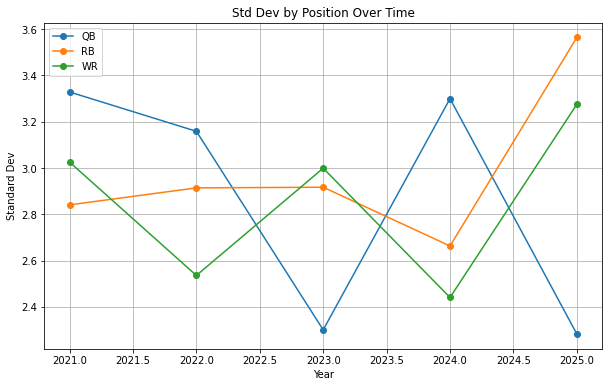

In [9]:
make_plots(plot_data,value_col='Standard Dev',title='Std Dev by Position Over Time', ylabel='Standard Dev')

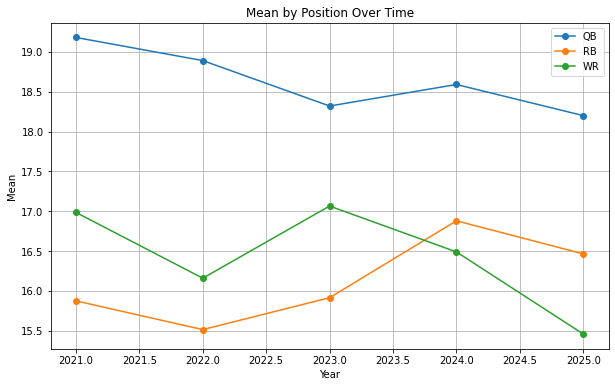

In [10]:
make_plots(plot_data,value_col='Mean',title='Mean by Position Over Time', ylabel='Mean')

**Key Insights**

It seems that my hypothesis holds some truth but many more faults. I stated that "It is my belief that it is best to target dominant WRs than dominant RBs as there tends to be more valuable RBs in later rounds, and RBs are more injury prone due to their usage in real life." 

From these plots we can understand the spread over the years and what position could be more valuable. The mean average for running backs stayed around the same from 2021-2023 with an increase from 2024-2025. In these years the average points were higher in WR than RBs by almost an entire point which is significant. The standard deviation suggests that the spread between the elite players and the rest of the pack was the same from 2021-2023, indicating that most players knew who the elite RBs were since they outperformed the rest of the pack that same way.

This changed significantly in 2025 where the elite running backs were much greater than the rest of their peers, while there was a dip in the average at the position from 2024.  

What we can gather from this information is that RBs are becoming more valuable with their average increasing since 2021, and their standard deviation rising. This shows that the elite are becoming more valuable and perhaps the rest of the group not performing as well. This gives more value to those top players at the RB position.

On the other hand, the pattern of rising standard deviation and a falling average is also found in the WR position. However, WRs have been falling since 2023 in their average points and at a much more significant rate with them being now an average point lower than RBs.

From this analysis, I believe that context of draft pick and the choices available still matter in to which position to take. I believe that there is a trend though that currently favors RBs, especially their elite counterparts rather than the elite WRs.

**Draft Dataset** Now time to create decision trees to figure out how the owners in my league draft. 

The dataset below was taken from the SleeperAPI and converted into a csv. It contains information about every draft pick in my fantasy league. Here you can see how the snake draft works. Owner12 gets to choose twice at the end of the round, and then it'll loop back to owner1.

In [11]:
draft_data = pd.read_csv('draft - Copy.csv')

In [12]:
draft_data.head(25)

,year,league_id,draft_id,overall_pick,round,draft_slot,player_id,player_name,position,roster_id,owner_name,unique_id
0,2025,XXXXXXXXXXXX,XXXXXXXXXXXX,1,1,1,7564,Ja'Marr Chase,WR,4,owner1,XXXXXXXXXXXX
1,2025,XXXXXXXXXXXX,XXXXXXXXXXXX,2,1,2,4866,Saquon Barkley,RB,11,owner2,XXXXXXXXXXXX
2,2025,XXXXXXXXXXXX,XXXXXXXXXXXX,3,1,3,9509,Bijan Robinson,RB,1,owner3,XXXXXXXXXXXX
3,2025,XXXXXXXXXXXX,XXXXXXXXXXXX,4,1,4,6794,Justin Jefferson,WR,12,owner4,XXXXXXXXXXXX
4,2025,XXXXXXXXXXXX,XXXXXXXXXXXX,5,1,5,9221,Jahmyr Gibbs,RB,7,owner5,XXXXXXXXXXXX
5,2025,XXXXXXXXXXXX,XXXXXXXXXXXX,6,1,6,6786,CeeDee Lamb,WR,10,owner6,XXXXXXXXXXXX
6,2025,XXXXXXXXXXXX,XXXXXXXXXXXX,7,1,7,9493,Puka Nacua,WR,6,owner7,XXXXXXXXXXXX
7,2025,XXXXXXXXXXXX,XXXXXXXXXXXX,8,1,8,3198,Derrick Henry,RB,2,owner8,XXXXXXXXXXXX
8,2025,XXXXXXXXXXXX,XXXXXXXXXXXX,9,1,9,4034,Christian McCaffrey,RB,8,owner9,XXXXXXXXXXXX
9,2025,XXXXXXXXXXXX,XXXXXXXXXXXX,10,1,10,7547,Amon-Ra St. Brown,WR,3,owner10,XXXXXXXXXXXX


The goal is to create a decision tree model for each owner and get a probability for each position at each round.
First I'll train on all seasons except the most recent. I'll use the most recent as my test set.

In [13]:
most_recent_year = draft_data['year'].max()
train_df = draft_data[draft_data['year'] < most_recent_year]
test_df = draft_data[draft_data['year'] == most_recent_year]

Now to train our models. I have removed the owners with the name owner_guest since they were guests
players that are no longer part of the league. As a side note, owner11 while REDACTED is actually my owner classifier. So it'll also be interesting to see how the model will predict me to draft. Below, I'm creating a train_models function. It will take in the max_depth of the tree. I have adjusted it several times,but have decided to choose max_depth of 10 because the heatmap captures tendencies from owners better with a higher max_depth. This will likely cause overfitting in metrics such as log loss and brier score. By raising the max depth, I'm creating more rules and combinations that might not be as available to train because of the sparse dataset. The heatmap smoothes these rules and combinations allowing me to be able to get a better image at the tendencies of each owner.

**Training the Model ** The code below returns a dictionary that has each model for each owner. Here I use LabelEncoder to encode positions as numbers for the model.
It also takes in a feature_matrix to then add to the DecisionTreeClassifier() which actually trains the model.
The for loop has "dataframe in copy_df.groupby('owner_name')" which creates a dataframe to create a model for each owner.

In [14]:


def train_models(df, max_depth, features):
    models = {}
    copy_df = df.copy()
    le = LabelEncoder().fit(copy_df['position'])
    copy_df = copy_df[~copy_df['owner_name'].isin(['owner_guest','owner_guest2','owner_guest3'])]
    #class_weight = {0:}
    for owner, dataframe in copy_df.groupby('owner_name'):
        feature_matrix = dataframe[features].values
        labels = le.transform(dataframe['position'])
        model = DecisionTreeClassifier(max_depth = max_depth, random_state = 123)
        model.fit(feature_matrix,labels)
        models[owner] = {'model':model,'label':le}
     
    return models




Here I train the model with the training dataset using the function above. For here we're only using the round feature, I'll add more features soon.

In [15]:
max_depth = 10

features= ['round']
models = train_models(train_df,max_depth,features)
train_models(train_df, max_depth, features)

{'owner1': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner10': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner11': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner12': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner2': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner3': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner4': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner5': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner6': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner7': {'model': DecisionTreeClassifier(max_dept

Now we can see the predictions that we get from the models:

In [16]:
def predict_round(models,owner,round_num):
    m = models[owner]
    probs = m['model'].predict_proba([[round_num]])[0]
    classes = m['label'].inverse_transform(m['model'].classes_)
    return pd.Series(probs,index =classes).sort_values(ascending=False)

predict_round(models,'owner11',2)

    

WR     0.75
RB     0.25
DEF    0.00
K      0.00
QB     0.00
TE     0.00
dtype: float64

** Engineering Features ** For the heatmap, I'd like to add more features. With such sparse data, this may make it look worse since we are creating more combinations than actual data points in the dataset on the evaluation metrics (log loss,etc), but it will work better for the heatmap. The goal is to see trends, not make an exact prediction of each draft pick. Below, I create the engineer_features function that helps create the features for the model. I use shift to get the previous two positions as a feature. This will help finding tendencies with the heatmap I will create later.

In [17]:
def engineer_features(df):
    copy_df = df.copy()
    copy_df = copy_df.sort_values(['year','draft_id','overall_pick'])
    
    copy_df['prev_pos1'] = (copy_df.groupby(['year','draft_id','owner_name'])['position'].shift(1).fillna('NULL'))
    copy_df['prev_pos2'] = (copy_df.groupby(['year','draft_id','owner_name'])['position'].shift(2).fillna('NULL'))

    label_prev1 = LabelEncoder()
    label_prev2 = LabelEncoder()
    copy_df['prev_pos1_encoded'] = label_prev1.fit_transform(copy_df['prev_pos1'])
    copy_df['prev_pos2_encoded'] = label_prev2.fit_transform(copy_df['prev_pos2'])
    return copy_df,label_prev1,label_prev2




Below we do the same we did above. Split the data and train the model with the new features using the train_models function.

In [18]:
features = ['round','prev_pos1_encoded','prev_pos2_encoded']
df,label_prev1,label_prev2 = engineer_features(draft_data)
most_recent_year = draft_data['year'].max()

train_df = df[df['year'] < most_recent_year]
test_df = df[df['year'] == most_recent_year]
print(train_df.columns)
models = train_models(train_df,max_depth,features)
train_models(train_df, max_depth, features)


Index(['year', 'league_id', 'draft_id', 'overall_pick', 'round', 'draft_slot',
       'player_id', 'player_name', 'position', 'roster_id', 'owner_name',
       'unique_id', 'prev_pos1', 'prev_pos2', 'prev_pos1_encoded',
       'prev_pos2_encoded'],
      dtype='object')


{'owner1': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner10': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner11': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner12': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner2': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner3': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner4': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner5': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner6': {'model': DecisionTreeClassifier(max_depth=10, random_state=123),
  'label': LabelEncoder()},
 'owner7': {'model': DecisionTreeClassifier(max_dept

We then need to get the predictions. Below, I got each prediction by inputting the owner and the features. I use .predict_prob()
to predict the probabilities and inverse_transform to transform back to the original labels.

In [40]:
def predict_features(models,owner, round_num, prev_pos1,prev_pos2):
    prev_pos1_encoded = label_prev1.transform([prev_pos1])[0]
    prev_pos2_encoded = label_prev2.transform([prev_pos2])[0]
    features= [round_num, prev_pos1_encoded,prev_pos2_encoded]
    m = models[owner]
    probs = m['model'].predict_proba([features])[0]
    classes = m['label'].inverse_transform(m['model'].classes_)

    return pd.Series(probs,index =classes).sort_values(ascending=False)

predict_features(models,'owner11',2, 'WR', 'WR')

TE     0.5
WR     0.5
DEF    0.0
K      0.0
QB     0.0
RB     0.0
dtype: float64

** Visualizations **Now we can create a heatmap averaging across all the previous position combinations per each round. I set the number of rounds to 15, and added one to the range as the only draft that did not go to 15 rounds was in 2021 which went 14. A list of all possible positions is used to average predictions across all previous position combinations per round, producing a smoothed probability matrix. We get those positions via the for loops p1 and p2. Then we get the average with the mean function for each round. We finish with plotting the matrix for which ever owner we input.

A heatmap is good here because it smooths out the overconfident predictions from rare position combinations that the model is likely to encounter due to the small dataset. The rare combinations like TE with K could be a rare combination and if then someone drafted a WR, and this combination only happened once, then it would be presented as 100 percent for whatever they picked next (WR in this scenario). The above output shows the predictions of after drafting two wide receivers in round 1 and round 2. The model then predicts 0.5% for WR and 0.5% for a TE will be chosen the next round. The heatmap averages this with pulling from previous drafts and combinations so this mistake gets diluted. 

In [20]:

def plot_heatmap(models, owner):
    positions = ['NULL', 'RB', 'WR', 'TE', 'QB', 'K', 'DEF']
    
    matrix = pd.DataFrame({r: pd.DataFrame([predict_features(models, owner, r, p1, p2) 
    for p1 in positions 
    for p2 in positions
    ]
    ).mean() for r in range(1, 16)}
    ).fillna(0)
    
    fig,ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(matrix, ax=ax, annot=True, fmt='.0%',
                cmap='coolwarm', vmin=0, vmax=1, linewidths=1)
    ax.set_title(f'{owner} Position Probability by Round')
    plt.tight_layout()
    plt.show()

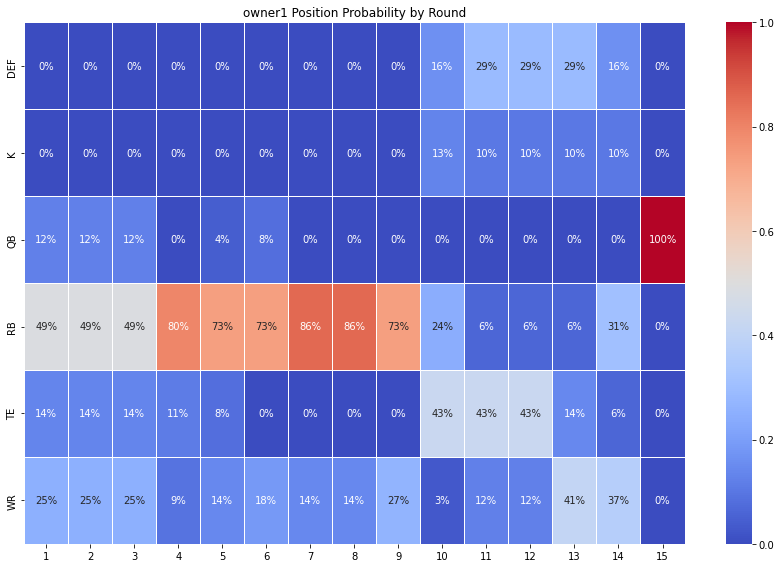

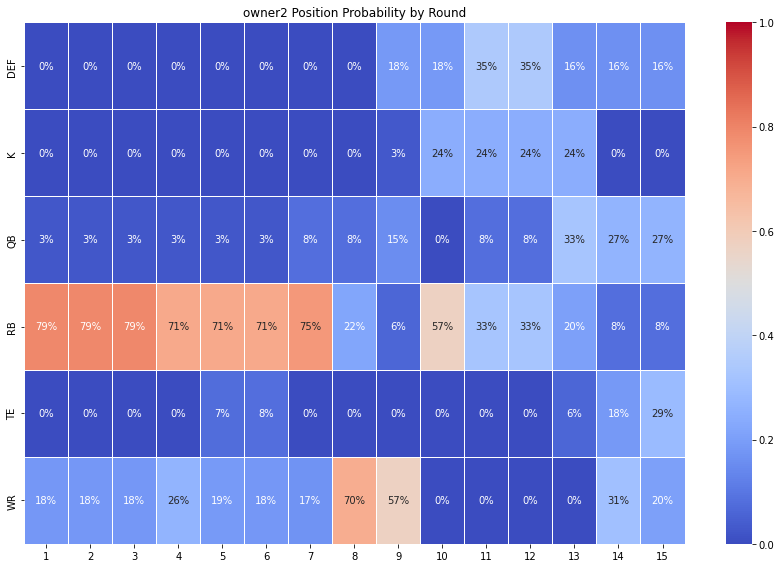

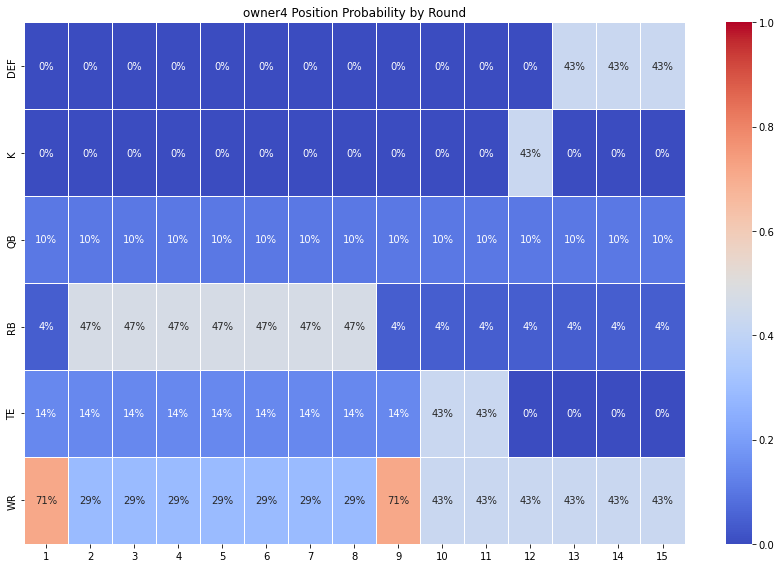

In [21]:
plot_heatmap(models, 'owner1')
plot_heatmap(models, 'owner2')
plot_heatmap(models, 'owner4')

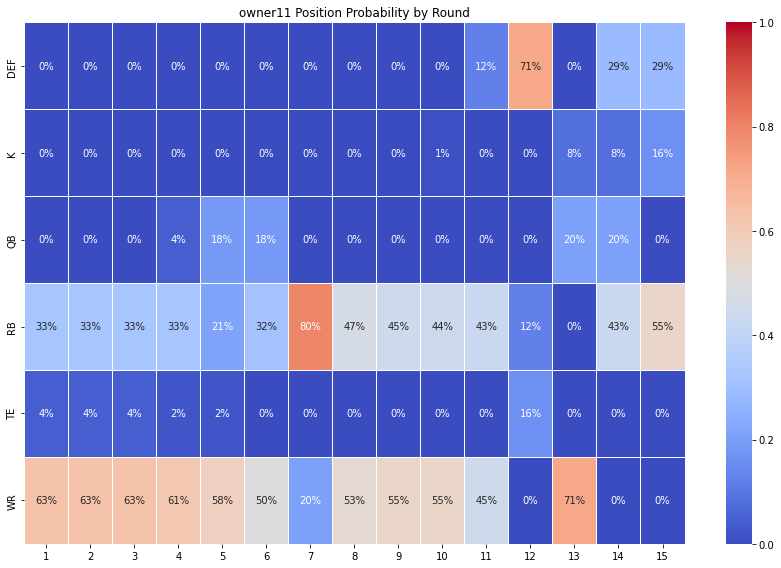

In [22]:
plot_heatmap(models,'owner11')

** Understanding Trends ** Prior to redacting the dataset, I made sure to note who each owner was on my own accord. It is good to discuss if the trends match my understanding though. I am owner11, and as I mentioned I historically favor WRs in earlier rounds and then favor getting RBs in the middle rounds. It seems that the heatmap was able to capture this tendency. It is not perfect though of course. The rare positions are very underrepresented which makes sense given the our small dataset. 

Lets also visualize my tree, I'm owner 11 so I decided to visualize mine. This will show how the model works.

In [23]:

def plot_trees(models, owner):
    fig,ax = plt.subplots(figsize = (12,8))
    plot_tree(models[owner]['model'],feature_names=['round','prev_pos1_encoded','prev_pos2_encoded'],
             class_names=models[owner]['label'].classes_,filled=True,fontsize=10,ax=ax)
    ax.set_title(f'{owner} Decision Tree',fontsize = 13)
    plt.tight_layout()
    plt.show()
    
    

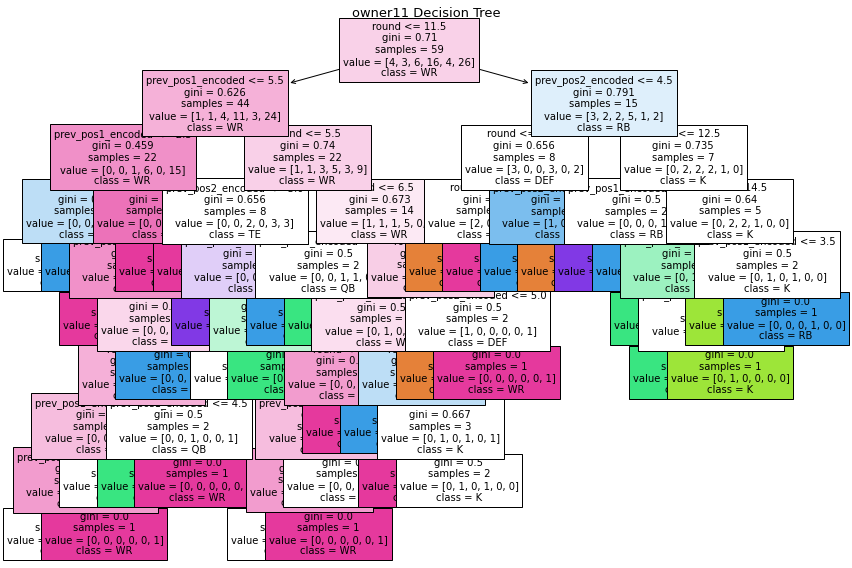

In [24]:
plot_trees(models,'owner11')

The tree model shows that I favor WR, which is true. We see it in the class that it mostly picks is WR. This tree is a little less readable, for more readability I could change the max_depth. It is able to find my tendencies of drafting which I explained earlier. I also want to know the effectiveness of the tree. A good metric is log-loss which we similarly use for logistic regression and probability models in general. I decided to also add brier score since log loss might penalize mistakes more harshly and with such a small dataset it may be very common.

Below I return a list metrics that contains dictionaries of the computed metrics. I again am removing the owner_guests which are no longer in the league. I'm computing these with the library sklearn.

In [25]:

def eval_models(df,test_df, features):
    metrics = []
    copy_df = test_df.copy()
    copy_df = copy_df[~copy_df['owner_name'].isin(['owner_guest','owner_guest2','owner_guest3'])]
    for owner, dataframe in copy_df.groupby('owner_name'):
        feature_matrix = dataframe[features].values
        m = models[owner]
        y_true = m['label'].transform(dataframe['position'])
        y_pred = m['model'].predict(feature_matrix)
        y_prob = m['model'].predict_proba(feature_matrix)
       
        
        brier_scores = []
        for i,pos in enumerate(m['model'].classes_):
            y_true_bin = (y_true == pos).astype(int)
            brier_scores.append(brier_score_loss(y_true_bin,y_prob[:,i]))
        metrics.append({'owner':owner,'accuracy':accuracy_score(y_true,y_pred
                                                                ),'log_loss':log_loss(y_true,y_prob,labels=m['model'].classes_),'brier_score':np.mean(brier_scores)})
    return metrics



In [26]:
eval_models(models,test_df,features)

[{'owner': 'owner1',
  'accuracy': 0.26666666666666666,
  'log_loss': 23.118270554015112,
  'brier_score': 0.23472222222222225},
 {'owner': 'owner10',
  'accuracy': 0.26666666666666666,
  'log_loss': 18.586341187271564,
  'brier_score': 0.18641975308641975},
 {'owner': 'owner11',
  'accuracy': 0.2,
  'log_loss': 23.164480366052445,
  'brier_score': 0.2388888888888889},
 {'owner': 'owner12',
  'accuracy': 0.4666666666666667,
  'log_loss': 16.275903891900427,
  'brier_score': 0.16805555555555554},
 {'owner': 'owner2',
  'accuracy': 0.4666666666666667,
  'log_loss': 13.981171001283478,
  'brier_score': 0.14830246913580247},
 {'owner': 'owner3',
  'accuracy': 0.3333333333333333,
  'log_loss': 20.81568546102107,
  'brier_score': 0.2125},
 {'owner': 'owner4',
  'accuracy': 0.2,
  'log_loss': 27.63102111592854,
  'brier_score': 0.26666666666666666},
 {'owner': 'owner5',
  'accuracy': 0.26666666666666666,
  'log_loss': 23.164480366052445,
  'brier_score': 0.2388888888888889},
 {'owner': 'owner

In [27]:
eval_models(models,train_df,features)

[{'owner': 'owner1',
  'accuracy': 0.9137931034482759,
  'log_loss': 0.14340976149516607,
  'brier_score': 0.016762452107279696},
 {'owner': 'owner10',
  'accuracy': 0.8448275862068966,
  'log_loss': 0.23315768168290332,
  'brier_score': 0.027777777777777776},
 {'owner': 'owner11',
  'accuracy': 0.864406779661017,
  'log_loss': 0.18797211676202394,
  'brier_score': 0.022598870056497175},
 {'owner': 'owner12',
  'accuracy': 0.8666666666666667,
  'log_loss': 0.2223282577905774,
  'brier_score': 0.025000000000000005},
 {'owner': 'owner2',
  'accuracy': 0.8983050847457628,
  'log_loss': 0.1733442147729504,
  'brier_score': 0.020244821092278723},
 {'owner': 'owner3',
  'accuracy': 0.9166666666666666,
  'log_loss': 0.13862943611199405,
  'brier_score': 0.016203703703703706},
 {'owner': 'owner4',
  'accuracy': 1.0,
  'log_loss': 5.188442268414911e-15,
  'brier_score': 0.0},
 {'owner': 'owner5',
  'accuracy': 0.8305084745762712,
  'log_loss': 0.23496514595252865,
  'brier_score': 0.02824858757

Here is the baseline log:

In [28]:
-np.log(1/6)

1.791759469228055

Here is the baseline brier score:

In [29]:
1/6 * (1 - 1/6)

0.1388888888888889

**Conclusion and Findings **

I used eval_metrics to find 3 key metrics in understanding the model's fit to the data. Initially, I simply looked at log_loss and accuracy, but after some research I learned that neither would be good to truly asses the quality of the model. Accuracy does not check the relationships/strategies, but rather what was picked. It is is nonetheless helpful to understanding how reliable the model is at predicting what position will be picked by an owner at a round, but it is not what this model is designed for and it makes sense why it is inaccurate especially with such a high max_depth of tree. We also see the overfitting due to the accuracy being much larger in the training set than test set.

Log loss is also not as helpful. The log loss between training set and test set are significantly different showing that the model overfits. This is likely due to the size of the dataset with the test set only being one draft and the training set being 4 drafts. It is also important to note that log loss heavily penalizes mistakes and with the small data set the model is more likely to make mistakes with the rare positions. TE, DEF, QB, and K are all subject to misclassifications since most players pick RB and WRs since they are the most valuable positions for PPR fantasy football.

It is also important to note that the reason as to why log loss is high in some owners. An auto-drafted team varies completely and would be incredibly difficult to model since there is no trend, the computer simply picks the player with the highest ADP, thus the larger log loss in owner 7 and owner 9 makes sense since these two players tend to autodraft past the second round.

Then there is the case of owner 4  who joined the league recently, so we only have two rounds of worth of draft data. 

For these reasons, I introduced brier score which is far more lenient on mistakes than log loss. The model performs substantially better under this perspective. The baseline for brier score is .139. In this scenario since we are simply using the 6 positions, it essentially represents a random guess. 

If we were to remove owners with limited data, and owners that autodraft (owner4,owner7,and owner 9):

In [30]:
lst = eval_models(models,test_df,features)
results = [i['brier_score'] for i in lst if i['owner'] not in  ['owner4','owner7','owner9']]

print(sum(results)/len(results))

0.2012002743484225


While not great, at instances where the max_depth was 3, the brier_score was actually smaller than .139. In this case, with the large depth, it is not good. 

** Better Models **
Better models can also certainly be explored. Decision trees aren't perfect in this scenario with limited data and the outcomes not being binary. There are patterns that it does not capture quite well when using evaluation metrics. The heatmap does a lot of the heavy lifting to capturing the patterns. 

A better approach may be simply counting the amount of times a person drafted a position at this point. This may be a better measuring tool and then creating a heatmap. Another may be using other probability models. 


** A Change In Draft Strategy **
With the findings from the mean and standard deviation plot, and how users tend to draft, I think it does call for some change in my overall drafting strategy. RBs are currently on the rise in the league and the use of WRs is going lower. The standard deviation last year rose significantly indicating the elite outperformed the rest of the field by a wide margin. RBs like Christian McCaffrey, Bijan Robinson, and Jamyr Gibbs were all great and averaged +20 points. 

In [31]:
top_rbs = data[(data['Pos'] == 'RB') & (data['Year'] == 2025)]
top_rbs_5 = top_rbs.nlargest(5,'AVG')

top_rbs_avg = top_rbs_5['AVG'].mean()
print(top_rbs_avg)
#top_rbs_5

21.880000000000003


The average for the top 5 RBs was 21.888. For the rest of the pack...

In [32]:
not_top_5_rb = top_rbs.drop(top_rbs_5.index)
print(not_top_5_rb['AVG'].mean())
#not_top_5_rb

14.66


It is 14.66.

In [33]:
top_wr = data[(data['Pos'] == 'WR') & (data['Year'] == 2025)]
top_wrs_5 = top_wr.nlargest(5,'AVG')
top_wrs_avg = top_wrs_5['AVG'].mean()
print(top_wrs_avg)
#top_wrs_5

20.099999999999998


The average for the top 5 WRs was 20.099. For the rest of the pack...

In [34]:
not_top_5_wr = top_wr.drop(top_wrs_5.index)
print(not_top_5_wr['AVG'].mean())
#not_top_5_wr

13.913333333333334


For the rest of the pack it is 13.91

** Final Thoughts ** The average for players 6-20 was 14.66 last season. The average points per game for WRs went down last year with the standard deviation increasing. This means less elite players with a likelihood of less impact on your fantasy team. In my past strategies I targeted elite WRs over RBs. Next season that will change with my main focus being the top RBs with a solid WR group. Again, it depends. I'm in a league where many favor drafting RB early, so if I'm in an opportunity to draft the best WR available I will. However, since the outside-top-5 RBs perform better with them averaging 14.66 to the WRs 13.91, I believe that hypothesis stands corrected. I also think with the implementation of two high safeties has limited WRs and has been a reason as to why WRs are now doing worse then RB. 

In the future, I will likely target the top 5 RBs and the top 3 WRs in the early rounds, and then focus more on a RB heavy team with solid WR depth.

** END **

**USEFUL LINKS**

https://medium.com/@sahilbansal480/understanding-model-calibration-in-machine-learning-6701814dbb3a

https://www.dratings.com/log-loss-vs-brier-score/

https://www.geeksforgeeks.org/machine-learning/implementing-cart-classification-and-regression-tree-in-python/

https://www.geeksforgeeks.org/machine-learning/ml-label-encoding-of-datasets-in-python/

https://seaborn.pydata.org/generated/seaborn.heatmap.html